In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys

project_root = Path().absolute().parent
sys.path.append(str(project_root))

from src.config import DATA_DIR, DEFAULT_CITY
from src.utils.data_utils import read_csv_async, run_parallel_analysis
from src.services.temperature_analysis_service import TemperatureAnalysisService
from src.services.visualization_service import TemperatureVisualizationService

from src.config import DATA_DIR


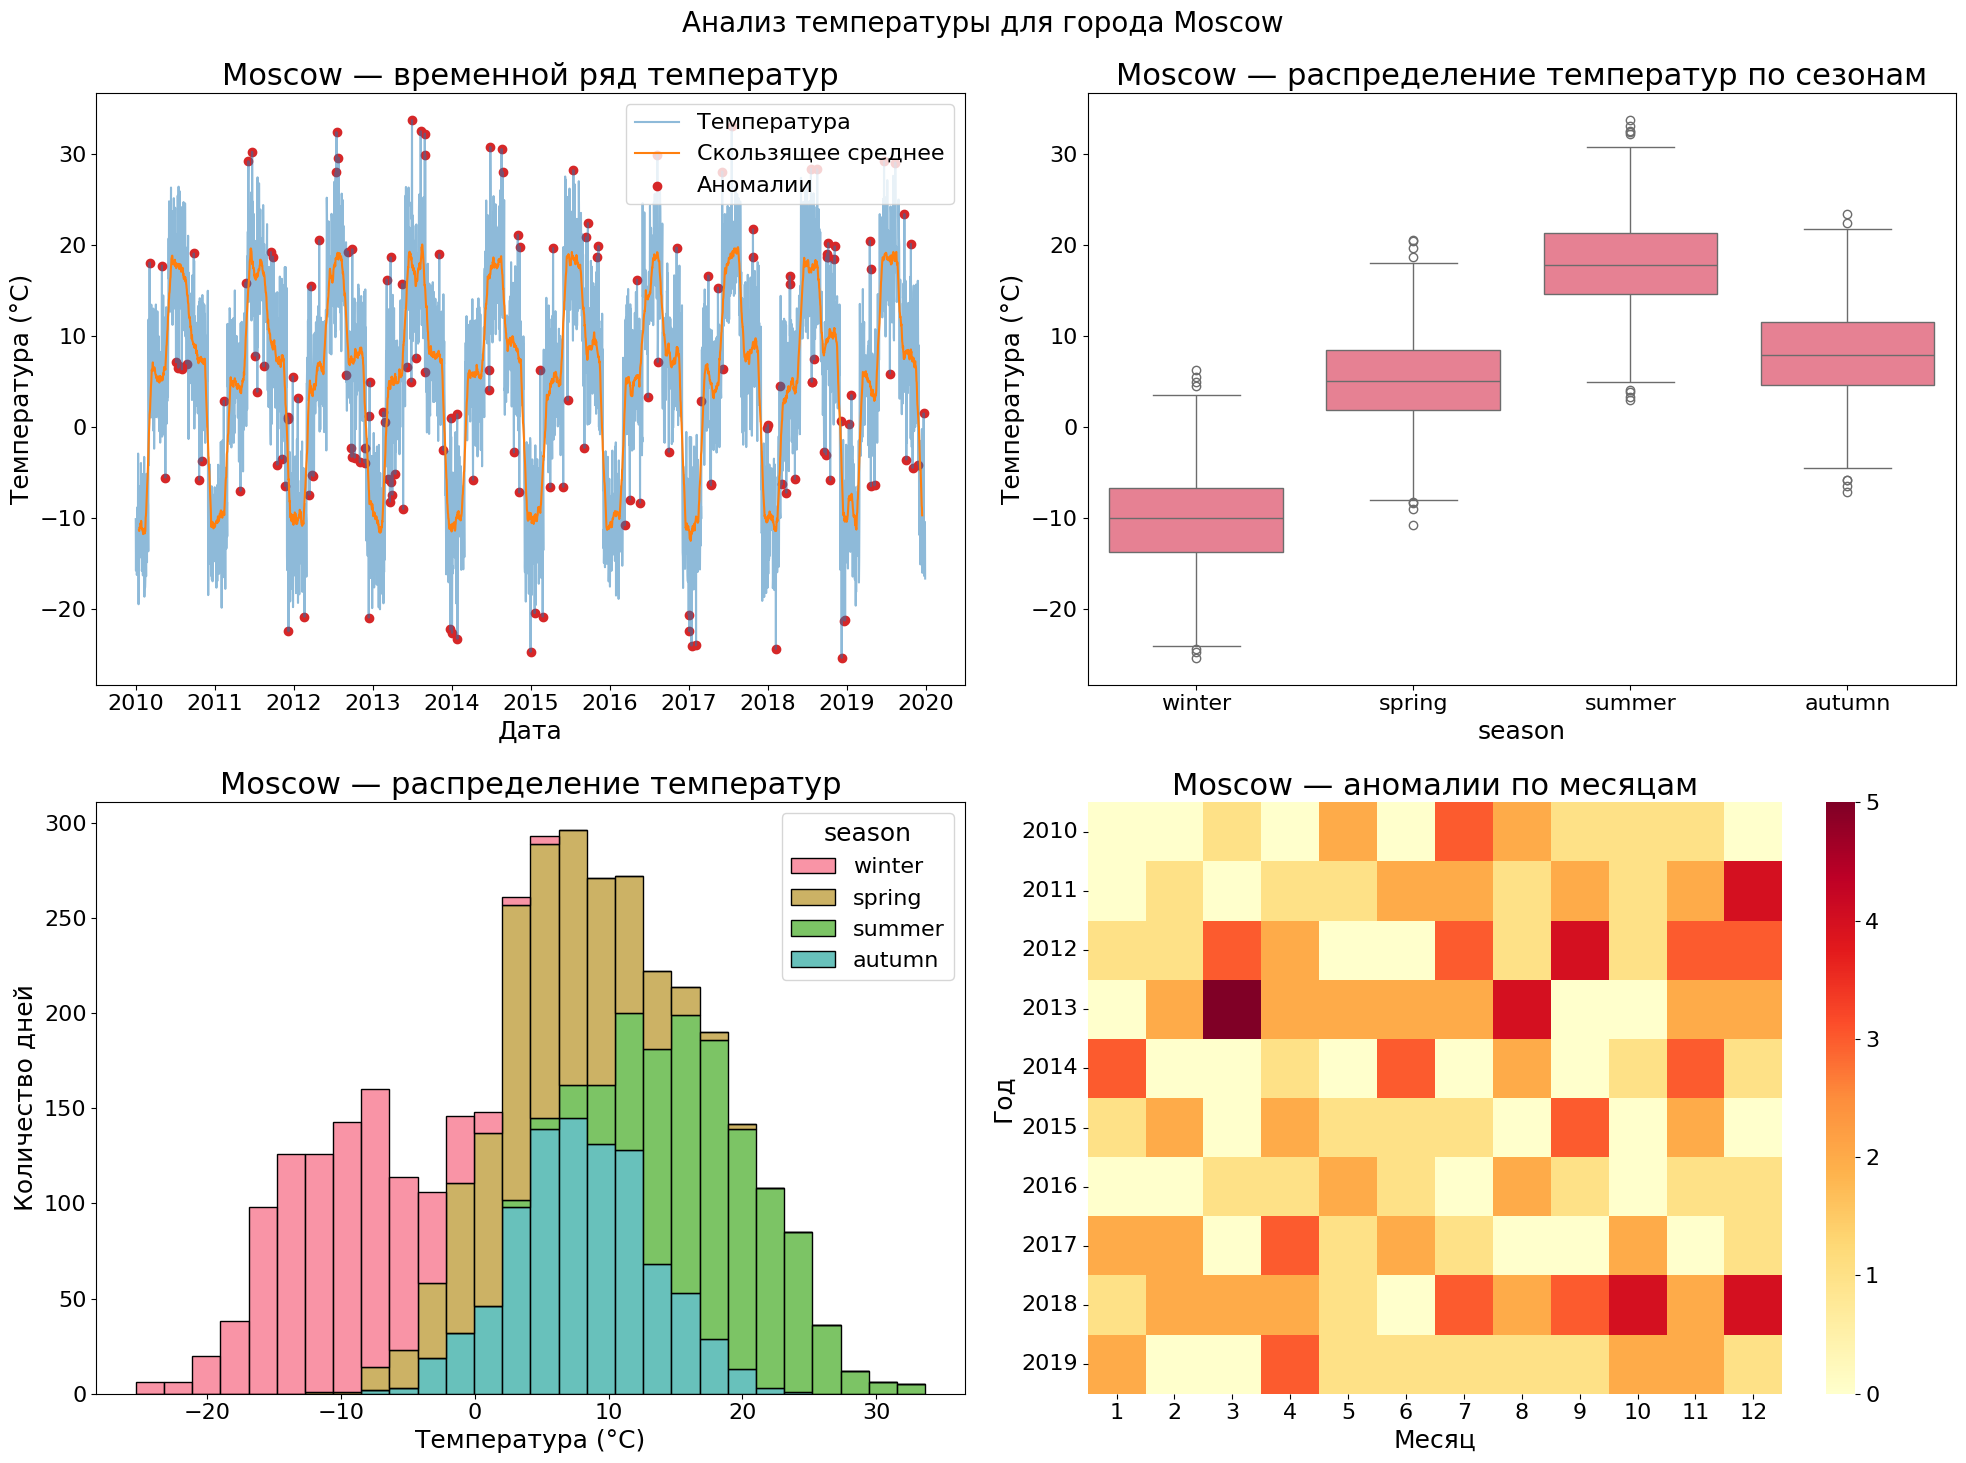

Сезонная статистика для города Moscow:
       temperature      
              mean   std
season                  
autumn        8.04  5.16
spring        5.06  5.07
summer       17.86  4.97
winter      -10.16  5.02

Общее количество аномалий: 165

Процент аномальных дней по сезонам:
        sum  count  percentage
season                        
autumn   45    910        4.95
spring   40    920        4.35
summer   43    920        4.67
winter   37    900        4.11


In [ ]:
plt.style.use('seaborn-v0_8-dark-palette')
sns.set_palette("husl")

data_file = DATA_DIR / "temperature_data.csv"

async def load_data(path):
    success, message, df = await read_csv_async(path)
    if not success:
        raise ValueError(message)
    return df

df = await load_data(data_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

async def analyze_cities(df):
    return await TemperatureAnalysisService.analyze_all_cities(df)

city_reports = await analyze_cities(df)

city_list = df['city'].unique()
city = DEFAULT_CITY if DEFAULT_CITY in city_list else city_list[0]
report = city_reports[city]
city_data = report.records
season_stats = report.seasonal_summary

viz = TemperatureVisualizationService()
viz.set_plot_style()

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle(f"Анализ температуры для города {city}", fontsize=20)

viz.draw_time_series(city_data, city, ax=axes[0,0])

viz.draw_season_boxplot(city_data, city, ax=axes[0,1])

viz.draw_temperature_histogram(city_data, city, ax=axes[1,0])

viz.draw_anomaly_heatmap(city_data, city, ax=axes[1,1])

plt.tight_layout()
plt.show()

print(f"Сезонная статистика для города {city}:\n{season_stats}")
print(f"\nОбщее количество аномалий: {city_data['is_anomaly'].sum()}")

seasonal_anomalies = city_data.groupby('season')['is_anomaly'].agg(['sum','count'])
seasonal_anomalies['percentage'] = (seasonal_anomalies['sum']/seasonal_anomalies['count']*100).round(2)
print("\nПроцент аномальных дней по сезонам:")
print(seasonal_anomalies)

# Исследование распараллеливания анализа

In [ ]:
# Сравнение последовательного и параллельного анализа
start_seq = time.time()

seq_results = {}
for city in city_list:
    report = await TemperatureAnalysisService.analyze_single_city(df, city)
    seq_results[city] = report

end_seq = time.time()
print(f"Последовательный анализ занял: {end_seq - start_seq:.2f} секунд")


Последовательный анализ занял: 0.11 секунд


In [6]:
# параллельный анализ
start_par = time.time()
par_results, par_time = run_parallel_analysis(df)
end_par = time.time()
print(f"Параллельный анализ занял: {end_par - start_par:.2f} секунд (время выполнения функции: {par_time:.2f} секунд)")

Параллельный анализ занял: 1.04 секунд (время выполнения функции: 0.94 секунд)


Вывод:
- на таком количестве данных параллельный анализ не дает выигрыша в скорости
